In [1]:
from detectron2.config import get_cfg
from detectron2.projects.deeplab import add_deeplab_config
from mask2former import add_maskformer2_config

In [2]:
cfg = get_cfg()
add_deeplab_config(cfg)
add_maskformer2_config(cfg)

cfg.merge_from_file('configs/maskformer2_R50_bs16_50ep.yaml')
cfg.MODEL.RESNETS.NORM = "BN"
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/panoptic/maskformer2_swin_large_IN21k_384_bs16_100ep/model_final_f07440.pkl'
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/instance/maskformer2_swin_base_384_bs16_50ep/model_final_f6e0f6.pkl'
#cfg.MODEL.WEIGHTS = './output/model_0049999.pth'
cfg.OUTPUT_DIR = "./test_output2/"

In [3]:
print(cfg)

CUDNN_BENCHMARK: False
DATALOADER:
  ASPECT_RATIO_GROUPING: True
  FILTER_EMPTY_ANNOTATIONS: True
  NUM_WORKERS: 4
  REPEAT_THRESHOLD: 0.0
  SAMPLER_TRAIN: TrainingSampler
DATASETS:
  PRECOMPUTED_PROPOSAL_TOPK_TEST: 1000
  PRECOMPUTED_PROPOSAL_TOPK_TRAIN: 2000
  PROPOSAL_FILES_TEST: ()
  PROPOSAL_FILES_TRAIN: ()
  TEST: ('coco_2017_val',)
  TRAIN: ('coco_2017_train',)
GLOBAL:
  HACK: 1.0
INPUT:
  COLOR_AUG_SSD: False
  CROP:
    ENABLED: False
    SINGLE_CATEGORY_MAX_AREA: 1.0
    SIZE: [0.9, 0.9]
    TYPE: relative_range
  DATASET_MAPPER_NAME: coco_instance_lsj
  FORMAT: RGB
  IMAGE_SIZE: 1024
  MASK_FORMAT: polygon
  MAX_SCALE: 2.0
  MAX_SIZE_TEST: 1333
  MAX_SIZE_TRAIN: 1333
  MIN_SCALE: 0.1
  MIN_SIZE_TEST: 800
  MIN_SIZE_TRAIN: (800,)
  MIN_SIZE_TRAIN_SAMPLING: choice
  RANDOM_FLIP: horizontal
  SIZE_DIVISIBILITY: -1
MODEL:
  ANCHOR_GENERATOR:
    ANGLES: [[-90, 0, 90]]
    ASPECT_RATIOS: [[0.5, 1.0, 2.0]]
    NAME: DefaultAnchorGenerator
    OFFSET: 0.0
    SIZES: [[32, 64, 128, 

In [4]:
cfg.freeze()

In [5]:
from detectron2.engine import (
    DefaultWSTrainer,
)
class Trainer(DefaultWSTrainer):
    """
    Extension of the Trainer class adapted to MaskFormer.
    """

    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        """
        Create evaluator(s) for a given dataset.
        This uses the special metadata "evaluator_type" associated with each
        builtin dataset. For your own dataset, you can simply create an
        evaluator manually in your script and do not have to worry about the
        hacky if-else logic here.
        """
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")
        evaluator_list = []
        evaluator_type = MetadataCatalog.get(dataset_name).evaluator_type
        # semantic segmentation
        if evaluator_type in ["sem_seg", "ade20k_panoptic_seg"]:
            evaluator_list.append(
                SemSegEvaluator(
                    dataset_name,
                    distributed=True,
                    output_dir=output_folder,
                )
            )
        # instance segmentation
        if evaluator_type == "coco":
            evaluator_list.append(COCOEvaluator(dataset_name, output_dir=output_folder))
        # panoptic segmentation
        if evaluator_type in [
            "coco_panoptic_seg",
            "ade20k_panoptic_seg",
            "cityscapes_panoptic_seg",
            "mapillary_vistas_panoptic_seg",
        ]:
            if cfg.MODEL.MASK_FORMER.TEST.PANOPTIC_ON:
                evaluator_list.append(COCOPanopticEvaluator(dataset_name, output_folder))
        # COCO
        if evaluator_type == "coco_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(COCOEvaluator(dataset_name, output_dir=output_folder))
        if evaluator_type == "coco_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
            evaluator_list.append(SemSegEvaluator(dataset_name, distributed=True, output_dir=output_folder))
        # Mapillary Vistas
        if evaluator_type == "mapillary_vistas_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(InstanceSegEvaluator(dataset_name, output_dir=output_folder))
        if evaluator_type == "mapillary_vistas_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
            evaluator_list.append(SemSegEvaluator(dataset_name, distributed=True, output_dir=output_folder))
        # Cityscapes
        if evaluator_type == "cityscapes_instance":
            assert (
                torch.cuda.device_count() > comm.get_rank()
            ), "CityscapesEvaluator currently do not work with multiple machines."
            return CityscapesInstanceEvaluator(dataset_name)
        if evaluator_type == "cityscapes_sem_seg":
            assert (
                torch.cuda.device_count() > comm.get_rank()
            ), "CityscapesEvaluator currently do not work with multiple machines."
            return CityscapesSemSegEvaluator(dataset_name)
        if evaluator_type == "cityscapes_panoptic_seg":
            if cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
                assert (
                    torch.cuda.device_count() > comm.get_rank()
                ), "CityscapesEvaluator currently do not work with multiple machines."
                evaluator_list.append(CityscapesSemSegEvaluator(dataset_name))
            if cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
                assert (
                    torch.cuda.device_count() > comm.get_rank()
                ), "CityscapesEvaluator currently do not work with multiple machines."
                evaluator_list.append(CityscapesInstanceEvaluator(dataset_name))
        # ADE20K
        if evaluator_type == "ade20k_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(InstanceSegEvaluator(dataset_name, output_dir=output_folder))
        # LVIS
        if evaluator_type == "lvis":
            return LVISEvaluator(dataset_name, output_dir=output_folder)
        if len(evaluator_list) == 0:
            raise NotImplementedError(
                "no Evaluator for the dataset {} with the type {}".format(
                    dataset_name, evaluator_type
                )
            )
        elif len(evaluator_list) == 1:
            return evaluator_list[0]
        return DatasetEvaluators(evaluator_list)

    @classmethod
    def build_train_loader(cls, cfg):
        # Semantic segmentation dataset mapper
        if cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_semantic":
            mapper = MaskFormerSemanticDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # Panoptic segmentation dataset mapper
        elif cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_panoptic":
            mapper = MaskFormerPanopticDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # Instance segmentation dataset mapper
        elif cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_instance":
            mapper = MaskFormerInstanceDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # coco instance segmentation lsj new baseline
        elif cfg.INPUT.DATASET_MAPPER_NAME == "coco_instance_lsj":
            mapper = COCOInstanceNewBaselineDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # coco panoptic segmentation lsj new baseline
        elif cfg.INPUT.DATASET_MAPPER_NAME == "coco_panoptic_lsj":
            mapper = COCOPanopticNewBaselineDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        else:
            mapper = None
            return build_detection_train_loader(cfg, mapper=mapper)

    @classmethod
    def build_lr_scheduler(cls, cfg, optimizer):
        """
        It now calls :func:`detectron2.solver.build_lr_scheduler`.
        Overwrite it if you'd like a different scheduler.
        """
        return build_lr_scheduler(cfg, optimizer)

    @classmethod
    def build_optimizer(cls, cfg, model):
        weight_decay_norm = cfg.SOLVER.WEIGHT_DECAY_NORM
        weight_decay_embed = cfg.SOLVER.WEIGHT_DECAY_EMBED

        defaults = {}
        defaults["lr"] = cfg.SOLVER.BASE_LR
        defaults["weight_decay"] = cfg.SOLVER.WEIGHT_DECAY

        norm_module_types = (
            torch.nn.BatchNorm1d,
            torch.nn.BatchNorm2d,
            torch.nn.BatchNorm3d,
            torch.nn.SyncBatchNorm,
            # NaiveSyncBatchNorm inherits from BatchNorm2d
            torch.nn.GroupNorm,
            torch.nn.InstanceNorm1d,
            torch.nn.InstanceNorm2d,
            torch.nn.InstanceNorm3d,
            torch.nn.LayerNorm,
            torch.nn.LocalResponseNorm,
        )

        params: List[Dict[str, Any]] = []
        memo: Set[torch.nn.parameter.Parameter] = set()
        for module_name, module in model.named_modules():
            for module_param_name, value in module.named_parameters(recurse=False):
                if not value.requires_grad:
                    continue
                # Avoid duplicating parameters
                if value in memo:
                    continue
                memo.add(value)

                hyperparams = copy.copy(defaults)
                if "backbone" in module_name:
                    hyperparams["lr"] = hyperparams["lr"] * cfg.SOLVER.BACKBONE_MULTIPLIER
                if (
                    "relative_position_bias_table" in module_param_name
                    or "absolute_pos_embed" in module_param_name
                ):
                    print(module_param_name)
                    hyperparams["weight_decay"] = 0.0
                if isinstance(module, norm_module_types):
                    hyperparams["weight_decay"] = weight_decay_norm
                if isinstance(module, torch.nn.Embedding):
                    hyperparams["weight_decay"] = weight_decay_embed
                params.append({"params": [value], **hyperparams})

        def maybe_add_full_model_gradient_clipping(optim):
            # detectron2 doesn't have full model gradient clipping now
            clip_norm_val = cfg.SOLVER.CLIP_GRADIENTS.CLIP_VALUE
            enable = (
                cfg.SOLVER.CLIP_GRADIENTS.ENABLED
                and cfg.SOLVER.CLIP_GRADIENTS.CLIP_TYPE == "full_model"
                and clip_norm_val > 0.0
            )

            class FullModelGradientClippingOptimizer(optim):
                def step(self, closure=None):
                    all_params = itertools.chain(*[x["params"] for x in self.param_groups])
                    torch.nn.utils.clip_grad_norm_(all_params, clip_norm_val)
                    super().step(closure=closure)

            return FullModelGradientClippingOptimizer if enable else optim

        optimizer_type = cfg.SOLVER.OPTIMIZER
        if optimizer_type == "SGD":
            optimizer = maybe_add_full_model_gradient_clipping(torch.optim.SGD)(
                params, cfg.SOLVER.BASE_LR, momentum=cfg.SOLVER.MOMENTUM
            )
        elif optimizer_type == "ADAMW":
            optimizer = maybe_add_full_model_gradient_clipping(torch.optim.AdamW)(
                params, cfg.SOLVER.BASE_LR
            )
        else:
            raise NotImplementedError(f"no optimizer type {optimizer_type}")
        if not cfg.SOLVER.CLIP_GRADIENTS.CLIP_TYPE == "full_model":
            optimizer = maybe_add_gradient_clipping(cfg, optimizer)
        return optimizer

    @classmethod
    def test_with_TTA(cls, cfg, model):
        logger = logging.getLogger("detectron2.trainer")
        # In the end of training, run an evaluation with TTA.
        logger.info("Running inference with test-time augmentation ...")
        model = SemanticSegmentorWithTTA(cfg, model)
        evaluators = [
            cls.build_evaluator(
                cfg, name, output_folder=os.path.join(cfg.OUTPUT_DIR, "inference_TTA")
            )
            for name in cfg.DATASETS.TEST
        ]
        res = cls.test(cfg, model, evaluators)
        res = OrderedDict({k + "_TTA": v for k, v in res.items()})
        return res

In [6]:
import torch
import copy
from detectron2.evaluation import (
    CityscapesInstanceEvaluator,
    CityscapesSemSegEvaluator,
    COCOEvaluator,
    COCOPanopticEvaluator,
    DatasetEvaluators,
    LVISEvaluator,
    SemSegEvaluator,
    verify_results,
)
from mask2former import (
    COCOInstanceNewBaselineDatasetMapper,
    COCOPanopticNewBaselineDatasetMapper,
    InstanceSegEvaluator,
    MaskFormerInstanceDatasetMapper,
    MaskFormerPanopticDatasetMapper,
    MaskFormerSemanticDatasetMapper,
    SemanticSegmentorWithTTA,
    add_maskformer2_config,
)
from detectron2.data import MetadataCatalog, build_detection_train_loader
from detectron2.projects.deeplab import build_lr_scheduler



In [7]:
print(cfg.OUTPUT_DIR)
print(cfg.MODEL.WEIGHTS)
#print(cfg.MODEL.WEIGHTS)


./test_output2/
https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/instance/maskformer2_R50_bs16_50ep/model_final_3c8ec9.pkl


In [8]:
import cv2
!wget http://images.cocodataset.org/val2017/000000005477.jpg -q -O input.jpg
im = cv2.imread("./input.jpg")
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

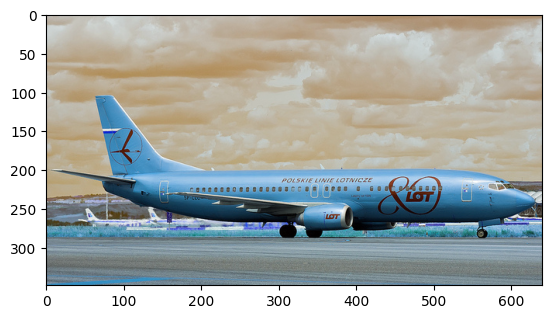

In [9]:
plt.imshow(im)

In [10]:
from detectron2.engine import DefaultPredictor
predictor = DefaultPredictor(cfg)
#predictor.model.backbone.set_active_subnet([0, 1, 3, 0])
outputs = predictor(im)


Weight format of MultiScaleMaskedTransformerDecoder have changed! Please upgrade your models. Applying automatic conversion now ...
Some model parameters or buffers are not found in the checkpoint:
backbone.res2.0.conv1.norm.num_batches_tracked
backbone.res2.0.conv2.norm.num_batches_tracked
backbone.res2.0.conv3.norm.num_batches_tracked
backbone.res2.0.shortcut.norm.num_batches_tracked
backbone.res2.1.conv1.norm.num_batches_tracked
backbone.res2.1.conv2.norm.num_batches_tracked
backbone.res2.1.conv3.norm.num_batches_tracked
backbone.res2.2.conv1.norm.num_batches_tracked
backbone.res2.2.conv2.norm.num_batches_tracked
backbone.res2.2.conv3.norm.num_batches_tracked
backbone.res3.0.conv1.norm.num_batches_tracked
backbone.res3.0.conv2.norm.num_batches_tracked
backbone.res3.0.conv3.norm.num_batches_tracked
backbone.res3.0.shortcut.norm.num_batches_tracked
backbone.res3.1.conv1.norm.num_batches_tracked
backbone.res3.1.conv2.norm.num_batches_tracked
backbone.res3.1.conv3.norm.num_batches_track

In [11]:
#print(outputs)

Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)
(418, 768, 3)


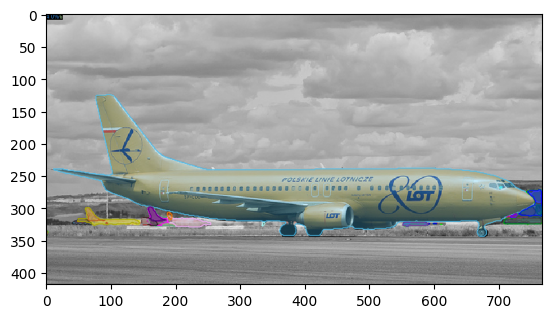

In [12]:
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog
import numpy as np

coco_metadata = MetadataCatalog.get("coco_2017_val_instance")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

In [36]:
#trainer = Trainer(cfg)

[04/18 18:16:22 d2.engine.defaults]: Model:
MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv3): Conv2d(


[04/18 18:16:37 d2.data.datasets.coco]: Loading datasets/coco/annotations/instances_train2017.json takes 14.42 seconds.
[04/18 18:16:38 d2.data.datasets.coco]: Loaded 118287 images in COCO format from datasets/coco/annotations/instances_train2017.json
[04/18 18:16:47 d2.data.build]: Removed 1021 images with no usable annotations. 117266 images left.
[04/18 18:16:50 d2.data.build]: Distribution of instances among all 80 categories:
|   category    | #instances   |   category   | #instances   |   category    | #instances   |
|:-------------:|:-------------|:------------:|:-------------|:-------------:|:-------------|
|    person     | 257253       |   bicycle    | 7056         |      car      | 43533        |
|  motorcycle   | 8654         |   airplane   | 5129         |      bus      | 6061         |
|     train     | 4570         |    truck     | 9970         |     boat      | 10576        |
| traffic light | 12842        | fire hydrant | 1865         |   stop sign   | 1983         |
|

In [14]:
import os
from detectron2.checkpoint import DetectionCheckpointer

model = Trainer.build_model(cfg)
print(model.backbone.stem.conv1.weight[0, 0, 0, :])
DetectionCheckpointer(model, save_dir=cfg.OUTPUT_DIR).resume_or_load(
    cfg.MODEL.WEIGHTS, resume=True
)
print(model.backbone.stem.conv1.weight[0, 0, 0, :])

Weight format of MultiScaleMaskedTransformerDecoder have changed! Please upgrade your models. Applying automatic conversion now ...
Some model parameters or buffers are not found in the checkpoint:
backbone.res2.0.conv1.norm.num_batches_tracked
backbone.res2.0.conv2.norm.num_batches_tracked
backbone.res2.0.conv3.norm.num_batches_tracked
backbone.res2.0.shortcut.norm.num_batches_tracked
backbone.res2.1.conv1.norm.num_batches_tracked
backbone.res2.1.conv2.norm.num_batches_tracked
backbone.res2.1.conv3.norm.num_batches_tracked
backbone.res2.2.conv1.norm.num_batches_tracked
backbone.res2.2.conv2.norm.num_batches_tracked
backbone.res2.2.conv3.norm.num_batches_tracked
backbone.res3.0.conv1.norm.num_batches_tracked
backbone.res3.0.conv2.norm.num_batches_tracked
backbone.res3.0.conv3.norm.num_batches_tracked
backbone.res3.0.shortcut.norm.num_batches_tracked
backbone.res3.1.conv1.norm.num_batches_tracked
backbone.res3.1.conv2.norm.num_batches_tracked
backbone.res3.1.conv3.norm.num_batches_track

tensor([-0.0395, -0.0287,  0.0176, -0.0159, -0.0174, -0.0180,  0.0122],
       device='cuda:0', grad_fn=<SliceBackward0>)
tensor([ 0.0117,  0.0119, -0.0149, -0.0214, -0.0358, -0.0367, -0.0593],
       device='cuda:0', grad_fn=<SliceBackward0>)


In [15]:
#print(model.backbone.stem.conv1.norm.weight)

In [16]:
from ofa.utils import AverageMeter, get_net_device, DistributedTensor
import copy
import torch.nn.functional as F
import torch.nn as nn
import random
import torch

#both group norm and batch norm updated
def set_running_statistics(model, data_loader, distributed=False):
    bn_mean = {}
    bn_var = {}

    gn_mean = {}
    gn_var = {}
    
    forward_model = copy.deepcopy(model)
    for name, m in forward_model.named_modules():
        if isinstance(m, nn.BatchNorm2d):
            if distributed:
                bn_mean[name] = DistributedTensor(name + "#mean")
                bn_var[name] = DistributedTensor(name + "#var")
            else:
                bn_mean[name] = AverageMeter()
                bn_var[name] = AverageMeter()

            def new_forward(bn, mean_est, var_est):
                def lambda_forward(x):
                    batch_mean = (
                        x.mean(0, keepdim=True)
                        .mean(2, keepdim=True)
                        .mean(3, keepdim=True)
                    )  # 1, C, 1, 1
                    batch_var = (x - batch_mean) * (x - batch_mean)
                    batch_var = (
                        batch_var.mean(0, keepdim=True)
                        .mean(2, keepdim=True)
                        .mean(3, keepdim=True)
                    )

                    batch_mean = torch.squeeze(batch_mean)
                    batch_var = torch.squeeze(batch_var)

                    mean_est.update(batch_mean.data, x.size(0))
                    var_est.update(batch_var.data, x.size(0))

                    # bn forward using calculated mean & var
                    _feature_dim = batch_mean.size(0)
                    return F.batch_norm(
                        x,
                        batch_mean,
                        batch_var,
                        bn.weight[:_feature_dim],
                        bn.bias[:_feature_dim],
                        False,
                        0.0,
                        bn.eps,
                    )

                return lambda_forward

            m.forward = new_forward(m, bn_mean[name], bn_var[name])
    
    if len(bn_mean) == 0:
        # skip if there is no batch normalization layers in the network
        return

    with torch.no_grad():
        count = 1
        #DynamicBatchNorm2d.SET_RUNNING_STATISTICS = True
        for input_images in data_loader:
            forward_model(input_images)
            count+=1
            if count >= 2500:
                break
            if count % 50 == 0:
                print(count)
        #DynamicBatchNorm2d.SET_RUNNING_STATISTICS = False

    for name, m in model.named_modules():
        if name in bn_mean and bn_mean[name].count > 0:
            feature_dim = bn_mean[name].avg.size(0)
            assert isinstance(m, nn.BatchNorm2d)
            m.running_mean.data[:feature_dim].copy_(bn_mean[name].avg)
            m.running_var.data[:feature_dim].copy_(bn_var[name].avg)

In [17]:
def count_parameters(model, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        #print(name)
        if not check_grad or (check_grad and parameter.requires_grad):
            count += parameter.numel()
    return count

In [18]:
total_num_param = count_parameters(model)
print(total_num_param)
def count_parameters_small(model, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if 'backbone' in name and 'res2' in name:
            if '0' in name and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res3' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res4' in name:
            if ('0' in name or '.1.' in name or '.2.' in name or '.3.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res5' in name:
            if '0' in name and parameter.requires_grad:
                print(name)
                count += parameter.numel()
        elif not check_grad or (check_grad and parameter.requires_grad):
            count += parameter.numel()
    return count
smallest_net_param = count_parameters_small(model)
print(smallest_net_param)
print(smallest_net_param/total_num_param)
print((total_num_param-smallest_net_param)/total_num_param)
def count_parameters_middle(model, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if 'backbone' in name and 'res2' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res3' in name:
            if ('0' in name or '.1.' in name or '.2.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res4' in name:
            if ('0' in name or '.1.' in name or '.2.' in name or '.3.' in name or '.4.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res5' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                print(name)
                count += parameter.numel()
        elif not check_grad or (check_grad and parameter.requires_grad):
            count += parameter.numel()
    return count

middle_net_param = count_parameters_middle(model)
print(middle_net_param)

44023377
backbone.res5.0.shortcut.weight
backbone.res5.0.shortcut.norm.weight
backbone.res5.0.shortcut.norm.bias
backbone.res5.0.conv1.weight
backbone.res5.0.conv1.norm.weight
backbone.res5.0.conv1.norm.bias
backbone.res5.0.conv2.weight
backbone.res5.0.conv2.norm.weight
backbone.res5.0.conv2.norm.bias
backbone.res5.0.conv3.weight
backbone.res5.0.conv3.norm.weight
backbone.res5.0.conv3.norm.bias
32162897
0.7305867743857997
0.2694132256142004
backbone.res5.0.shortcut.weight
backbone.res5.0.shortcut.norm.weight
backbone.res5.0.shortcut.norm.bias
backbone.res5.0.conv1.weight
backbone.res5.0.conv1.norm.weight
backbone.res5.0.conv1.norm.bias
backbone.res5.0.conv2.weight
backbone.res5.0.conv2.norm.weight
backbone.res5.0.conv2.norm.bias
backbone.res5.0.conv3.weight
backbone.res5.0.conv3.norm.weight
backbone.res5.0.conv3.norm.bias
backbone.res5.1.conv1.weight
backbone.res5.1.conv1.norm.weight
backbone.res5.1.conv1.norm.bias
backbone.res5.1.conv2.weight
backbone.res5.1.conv2.norm.weight
backbone

In [19]:
#train_data_loader = trainer.build_train_loader(cfg)

In [20]:
print(model.backbone.set_max_net())
print(model.backbone.runtime_depth)
#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'depth_list': [2, 2, 2, 2]}
{'res2': 0, 'res3': 0, 'res4': 0, 'res5': 0}
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3
Loading and preparing results...
DONE (t=0.26s)
creating index...
index created!
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] =

In [21]:
import warnings
warnings.filterwarnings('ignore')
print(model.backbone.runtime_depth)
print(model.backbone.sample_active_subnet())
model.backbone.set_active_subnet(depth_list=[0, 0, 0, 0])
print(model.backbone.runtime_depth)
#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 0, 'res3': 0, 'res4': 0, 'res5': 0}
{'depth_list': [0, 2, 2, 1]}
{'res2': 2, 'res3': 2, 'res4': 2, 'res5': 2}
res2 2 1
3 1
res3 2 2
4 2
res4 2 4
6 4
res5 2 1
3 1
Loading and preparing results...
DONE (t=0.21s)
creating index...
index created!
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ 

In [22]:
import warnings
warnings.filterwarnings('ignore')
print(model.backbone.runtime_depth)
print(model.backbone.sample_active_subnet())
model.backbone.set_active_subnet(depth_list=[1, 1, 1, 1])
print(model.backbone.runtime_depth)
#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 2, 'res3': 2, 'res4': 2, 'res5': 2}
{'depth_list': [1, 1, 0, 1]}
{'res2': 1, 'res3': 1, 'res4': 1, 'res5': 1}
res2 1 2
3 2
res3 1 3
4 3
res4 1 5
6 5
res5 1 2
3 2
Loading and preparing results...
DONE (t=0.22s)
creating index...
index created!
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ 

In [23]:
#set_running_statistics(trainer._trainer.model, train_data_loader)

In [24]:
'''print(type(train_data_loader.dataset.dataset), train_data_loader.dataset.dataset.sampler._size, train_data_loader.batch_size)
for item in train_data_loader:
    print(item[0].keys())
    print(trainer._trainer.model(item))'''

'print(type(train_data_loader.dataset.dataset), train_data_loader.dataset.dataset.sampler._size, train_data_loader.batch_size)\nfor item in train_data_loader:\n    print(item[0].keys())\n    print(trainer._trainer.model(item))'

In [25]:
print(cfg)

CUDNN_BENCHMARK: False
DATALOADER:
  ASPECT_RATIO_GROUPING: True
  FILTER_EMPTY_ANNOTATIONS: True
  NUM_WORKERS: 4
  REPEAT_THRESHOLD: 0.0
  SAMPLER_TRAIN: TrainingSampler
DATASETS:
  PRECOMPUTED_PROPOSAL_TOPK_TEST: 1000
  PRECOMPUTED_PROPOSAL_TOPK_TRAIN: 2000
  PROPOSAL_FILES_TEST: ()
  PROPOSAL_FILES_TRAIN: ()
  TEST: ('coco_2017_val',)
  TRAIN: ('coco_2017_train',)
GLOBAL:
  HACK: 1.0
INPUT:
  COLOR_AUG_SSD: False
  CROP:
    ENABLED: False
    SINGLE_CATEGORY_MAX_AREA: 1.0
    SIZE: [0.9, 0.9]
    TYPE: relative_range
  DATASET_MAPPER_NAME: coco_instance_lsj
  FORMAT: RGB
  IMAGE_SIZE: 1024
  MASK_FORMAT: polygon
  MAX_SCALE: 2.0
  MAX_SIZE_TEST: 1333
  MAX_SIZE_TRAIN: 1333
  MIN_SCALE: 0.1
  MIN_SIZE_TEST: 800
  MIN_SIZE_TRAIN: (800,)
  MIN_SIZE_TRAIN_SAMPLING: choice
  RANDOM_FLIP: horizontal
  SIZE_DIVISIBILITY: -1
MODEL:
  ANCHOR_GENERATOR:
    ANGLES: [[-90, 0, 90]]
    ASPECT_RATIOS: [[0.5, 1.0, 2.0]]
    NAME: DefaultAnchorGenerator
    OFFSET: 0.0
    SIZES: [[32, 64, 128, 

In [26]:
print(model.backbone.sample_active_subnet())

{'depth_list': [2, 0, 0, 0]}


Weight format of MultiScaleMaskedTransformerDecoder have changed! Please upgrade your models. Applying automatic conversion now ...
Some model parameters or buffers are not found in the checkpoint:
backbone.res2.0.conv1.norm.num_batches_tracked
backbone.res2.0.conv2.norm.num_batches_tracked
backbone.res2.0.conv3.norm.num_batches_tracked
backbone.res2.0.shortcut.norm.num_batches_tracked
backbone.res2.1.conv1.norm.num_batches_tracked
backbone.res2.1.conv2.norm.num_batches_tracked
backbone.res2.1.conv3.norm.num_batches_tracked
backbone.res2.2.conv1.norm.num_batches_tracked
backbone.res2.2.conv2.norm.num_batches_tracked
backbone.res2.2.conv3.norm.num_batches_tracked
backbone.res3.0.conv1.norm.num_batches_tracked
backbone.res3.0.conv2.norm.num_batches_tracked
backbone.res3.0.conv3.norm.num_batches_tracked
backbone.res3.0.shortcut.norm.num_batches_tracked
backbone.res3.1.conv1.norm.num_batches_tracked
backbone.res3.1.conv2.norm.num_batches_tracked
backbone.res3.1.conv3.norm.num_batches_track

Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)
(418, 768, 3)


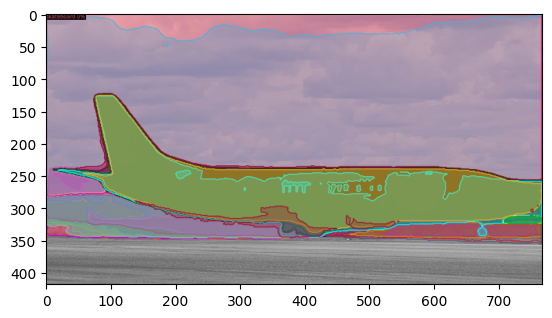

In [27]:
predictor = DefaultPredictor(cfg)
predictor.model.backbone.set_active_subnet([0, 0, 0, 0])
outputs = predictor(im)
coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

Weight format of MultiScaleMaskedTransformerDecoder have changed! Please upgrade your models. Applying automatic conversion now ...
Some model parameters or buffers are not found in the checkpoint:
backbone.res2.0.conv1.norm.num_batches_tracked
backbone.res2.0.conv2.norm.num_batches_tracked
backbone.res2.0.conv3.norm.num_batches_tracked
backbone.res2.0.shortcut.norm.num_batches_tracked
backbone.res2.1.conv1.norm.num_batches_tracked
backbone.res2.1.conv2.norm.num_batches_tracked
backbone.res2.1.conv3.norm.num_batches_tracked
backbone.res2.2.conv1.norm.num_batches_tracked
backbone.res2.2.conv2.norm.num_batches_tracked
backbone.res2.2.conv3.norm.num_batches_tracked
backbone.res3.0.conv1.norm.num_batches_tracked
backbone.res3.0.conv2.norm.num_batches_tracked
backbone.res3.0.conv3.norm.num_batches_tracked
backbone.res3.0.shortcut.norm.num_batches_tracked
backbone.res3.1.conv1.norm.num_batches_tracked
backbone.res3.1.conv2.norm.num_batches_tracked
backbone.res3.1.conv3.norm.num_batches_track

Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)
(418, 768, 3)


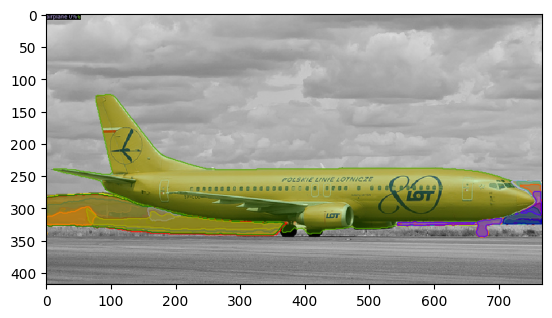

In [28]:
predictor = DefaultPredictor(cfg)
predictor.model.backbone.set_active_subnet([1, 1, 1, 1])
outputs = predictor(im)
coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

In [35]:
print(model.backbone.stem.conv1.norm.weight)

Parameter containing:
tensor([2.3888e-01, 2.9136e-01, 3.1615e-01, 2.7122e-01, 2.1731e-01, 3.0903e-01,
        2.2937e-01, 2.3086e-01, 2.1129e-01, 2.8054e-01, 1.9923e-01, 3.1894e-01,
        1.7955e-01, 1.1246e-08, 1.9704e-01, 2.0996e-01, 2.4317e-01, 2.1697e-01,
        1.9415e-01, 3.1569e-01, 1.9648e-01, 2.3214e-01, 2.1962e-01, 2.1633e-01,
        2.4357e-01, 2.9683e-01, 2.3852e-01, 2.1162e-01, 1.4492e-01, 2.9388e-01,
        2.2911e-01, 9.2716e-02, 4.3334e-01, 2.0782e-01, 2.7990e-01, 3.5804e-01,
        2.9315e-01, 2.5306e-01, 2.4210e-01, 2.1755e-01, 3.8645e-01, 2.1003e-01,
        3.6805e-01, 3.3724e-01, 5.0826e-01, 1.9341e-01, 2.3914e-01, 2.6652e-01,
        3.9020e-01, 1.9840e-01, 2.1694e-01, 2.6666e-01, 4.9806e-01, 2.3553e-01,
        2.1349e-01, 2.5951e-01, 2.3547e-01, 1.7579e-01, 4.5354e-01, 1.7102e-01,
        2.4903e-01, 2.5148e-01, 3.8020e-01, 1.9665e-01], device='cuda:0',
       requires_grad=True)
